# NLP Text Summarization — End-to-End Project

> **Project Type:** Intermediate NLP  
> **Task:** Automatic text summarization using extractive and abstractive approaches  
> **Models:** TF-IDF Extractive Baseline · BART Transformer (abstractive)  
> **Evaluation:** ROUGE-1, ROUGE-2, ROUGE-L  

---

## Table of Contents
1. [Project Overview](#1-project-overview)  
2. [Setup & Imports](#2-setup--imports)  
3. [Dataset Creation & Loading](#3-dataset-creation--loading)  
4. [Exploratory Data Analysis (EDA)](#4-exploratory-data-analysis-eda)  
5. [Data Cleaning & Preprocessing](#5-data-cleaning--preprocessing)  
6. [Extractive Summarization (TF-IDF Baseline)](#6-extractive-summarization-tf-idf-baseline)  
7. [Abstractive Summarization (BART Transformer)](#7-abstractive-summarization-bart-transformer)  
8. [Model Evaluation with ROUGE Scores](#8-model-evaluation-with-rouge-scores)  
9. [Comparison & Visualization](#9-comparison--visualization)  
10. [Interactive Summarizer](#10-interactive-summarizer)  
11. [Conclusions & Future Work](#11-conclusions--future-work)

---
## 1. Project Overview

**Problem Statement:**  
Summarize long news articles automatically, producing concise and accurate summaries that preserve the essential information.

**Approach:**
- **Dataset:** Synthetic corpus of 20 news articles across 5 categories (Technology, Health, Science, Business, Environment), created with matching human reference summaries.
- **Extractive Model:** TF-IDF sentence scoring — scores each sentence by the importance of its words, then selects top-k sentences.
- **Abstractive Model:** BART (`facebook/bart-large-cnn`) — a pre-trained transformer sequence-to-sequence model fine-tuned for summarization.
- **Evaluation:** ROUGE metrics (Recall-Oriented Understudy for Gisting Evaluation) compare generated summaries against human reference summaries.

**Python Libraries:**
- `pandas`, `numpy` — data handling
- `matplotlib`, `seaborn` — visualization
- `nltk`, `scikit-learn` — NLP preprocessing & TF-IDF
- `transformers` (HuggingFace) — BART model
- `rouge-score` — ROUGE evaluation

---
## 2. Setup & Imports

In [1]:
# ── Install required packages (run once) ──────────────────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

required = ['nltk', 'scikit-learn', 'matplotlib', 'seaborn', 'transformers', 'torch', 'sentencepiece', 'tqdm']
for pkg in required:
    try:
        __import__(pkg.replace('-','_'))
    except ImportError:
        print(f'Installing {pkg}...')
        install(pkg)

print('All packages ready ✓')
print('NOTE: rouge_score is NOT required — ROUGE is implemented from scratch in Section 8.')

Installing scikit-learn...
Installing transformers...
Installing torch...
Installing sentencepiece...
All packages ready ✓
NOTE: rouge_score is NOT required — ROUGE is implemented from scratch in Section 8.


In [2]:
import os
import re
import csv
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.corpus import stopwords

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity


# Download NLTK data
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)
nltk.download('stopwords', quiet=True)

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)
plt.rcParams['figure.dpi'] = 120

print('All imports successful ✓')
print(f'Pandas  : {pd.__version__}')
print(f'NumPy   : {np.__version__}')

All imports successful ✓
Pandas  : 2.3.3
NumPy   : 2.3.5


---
## 3. Dataset Creation & Loading

We use a hand-crafted synthetic dataset of 20 real-world-style news articles across 5 categories.  
Each article comes with a professional reference summary.

The dataset was generated via `data/generate_dataset.py`, which writes:  
- `data/articles.csv` — article id, category, full text  
- `data/summaries.csv` — article id, reference summary

In [3]:
# ─── Embedded raw data (so the notebook is self-contained) ──────────────────
RAW_DATA = [
    {
        "id": 1, "category": "Technology",
        "article": (
            "Artificial intelligence company OpenAI announced the release of GPT-4, a large multimodal model "
            "that accepts image and text inputs and emits text outputs. GPT-4 exhibits human-level performance "
            "on various professional and academic benchmarks. For example, it passes a simulated bar exam with "
            "a score around the top 10% of test takers. OpenAI spent six months using adversarial testing "
            "prior to release. The model can solve difficult problems with greater accuracy, thanks to its "
            "broader general knowledge and problem-solving abilities. GPT-4 is more reliable, creative, and "
            "able to handle much more nuanced instructions than its predecessor GPT-3.5. The model was also "
            "evaluated on traditional benchmarks designed for machine learning models, including academic "
            "exams such as the Uniform Bar Examination, LSAT, SAT Math, and SAT Evidence-Based Reading & "
            "Writing. GPT-4 substantially outperforms existing large language models, alongside most "
            "state-of-the-art models. However, GPT-4 is not without its limitations. The model can hallucinate "
            "facts and make reasoning errors. The model's knowledge is also limited to its training data, "
            "meaning it may not have up-to-date information. OpenAI plans to improve these aspects over time "
            "through iterative deployment and feedback from real-world use."
        ),
        "summary": (
            "OpenAI released GPT-4, a multimodal AI model that achieves human-level performance on academic "
            "benchmarks including the bar exam, though it still has limitations like hallucinations and a "
            "fixed knowledge cutoff."
        )
    },
    {
        "id": 2, "category": "Health",
        "article": (
            "A new study published in the New England Journal of Medicine found that a Mediterranean diet "
            "supplemented with extra-virgin olive oil or mixed nuts reduces the risk of major cardiovascular "
            "events by approximately 30% compared to a control diet. The study, known as PREDIMED, involved "
            "7,447 participants aged 55 to 80 years who were at high cardiovascular risk but had no "
            "cardiovascular disease at enrollment. Participants were randomly assigned to one of three "
            "dietary groups. The primary endpoint was a composite of myocardial infarction, stroke, or "
            "death from cardiovascular causes. The trial was stopped early because the results were so "
            "compelling. Researchers noted that the Mediterranean diet is rich in fruits, vegetables, "
            "legumes, whole grains, fish, and olive oil. It also involves moderate consumption of alcohol, "
            "mainly wine, and low consumption of red meat, dairy products, and processed foods. The findings "
            "reinforce previous observational studies suggesting the Mediterranean diet is one of the "
            "healthiest dietary patterns in the world. Nutritionists recommend the diet not just for heart "
            "health but also for its potential benefits in reducing the risk of type 2 diabetes, certain "
            "cancers, and cognitive decline."
        ),
        "summary": (
            "A major clinical trial found that a Mediterranean diet supplemented with olive oil or nuts "
            "reduces cardiovascular event risk by 30%, supporting it as one of the world's healthiest "
            "dietary patterns."
        )
    },
    {
        "id": 3, "category": "Science",
        "article": (
            "NASA's James Webb Space Telescope has captured the deepest infrared image of the universe ever "
            "taken, showing galaxy cluster SMACS 0723 as it appeared 4.6 billion years ago. The image covers "
            "a patch of sky approximately the size of a grain of sand held at arm's length by someone on "
            "the ground. Thousands of galaxies, including the faintest objects ever observed in the infrared, "
            "have appeared in Webb's view for the first time. Webb's First Deep Field was released by "
            "President Biden at the White House on July 11, 2022. The telescope also released spectra of "
            "WASP-96b, a giant planet outside our solar system composed partly of water, demonstrating "
            "Webb's unprecedented ability to analyze atmospheres hundreds of light-years away. The Southern "
            "Ring Nebula, a planetary nebula, was imaged in stunning detail, revealing a previously hidden "
            "second star at its center. Webb also captured Stephan's Quintet, a visual grouping of five "
            "galaxies, providing new insights into how galactic interactions trigger star formation and "
            "drive the growth of galaxies. Scientists around the world have been analyzing the data and "
            "publishing findings across multiple disciplines from cosmology to planetary science."
        ),
        "summary": (
            "NASA's James Webb Space Telescope released its first images, including the deepest infrared "
            "view of the universe ever taken and exoplanet atmospheric data, opening new frontiers in "
            "astronomy and cosmology."
        )
    },
    {
        "id": 4, "category": "Business",
        "article": (
            "Electric vehicle maker Tesla reported record quarterly revenue of $21.3 billion in its fourth "
            "quarter earnings, surpassing analyst expectations. The company delivered 405,278 vehicles "
            "during the quarter, a new record and a 31% increase over the same period last year. Tesla's "
            "net income reached $3.7 billion for the quarter. CEO Elon Musk noted the company continues "
            "to face significant headwinds from the global macroeconomic environment, including high "
            "interest rates which make car purchases less affordable for consumers. Despite this, Tesla "
            "maintained its industry-leading operating margin of 17.2%. The company also revealed progress "
            "on its next-generation vehicle platform, which is expected to reduce manufacturing costs "
            "significantly. Tesla's energy generation and storage segment also saw strong growth, with "
            "revenue up 40% year-over-year. The company reaffirmed its long-term target of 50% annual "
            "vehicle delivery growth and announced plans to expand its Gigafactory network. Shares rose "
            "in after-hours trading following the earnings report."
        ),
        "summary": (
            "Tesla posted record Q4 revenue of $21.3 billion with 405,278 vehicle deliveries, up 31% "
            "year-over-year, while maintaining a 17.2% operating margin despite macroeconomic challenges."
        )
    },
    {
        "id": 5, "category": "Environment",
        "article": (
            "The Intergovernmental Panel on Climate Change released its sixth assessment report, "
            "concluding that human-caused climate change is widespread, rapid and intensifying. The "
            "report states that global surface temperature has increased faster since 1970 than in any "
            "other 50-year period over at least the last 2000 years. Current atmospheric concentrations "
            "of carbon dioxide are higher than at any time in at least 2 million years. Each of the last "
            "four decades has been successively warmer than any decade that preceded it since 1850. "
            "The report projects that global warming of 1.5C and 2C will be exceeded during the 21st "
            "century unless deep reductions in CO2 and other greenhouse gas emissions occur in the coming "
            "decades. Even with emissions cuts, some changes are already locked in for centuries or "
            "millennia. Sea level rise, which is accelerating, will continue throughout this century. "
            "Extreme heat events, heavy precipitation, droughts, and tropical cyclones are expected to "
            "become more frequent and severe. The report emphasizes that immediate and ambitious action "
            "is required to prevent the most catastrophic outcomes, stressing that every fraction of a "
            "degree of warming matters."
        ),
        "summary": (
            "The IPCC's sixth assessment report confirms that human-driven climate change is accelerating "
            "at unprecedented rates, with 1.5C and 2C warming thresholds likely to be breached without "
            "immediate deep emissions cuts."
        )
    },
    {
        "id": 6, "category": "Technology",
        "article": (
            "Apple unveiled its Vision Pro mixed reality headset at its Worldwide Developers Conference, "
            "describing it as a spatial computing device that seamlessly blends digital content with the "
            "physical world. The device, priced at $3,499, features micro-OLED displays that provide "
            "more pixels than a 4K TV for each eye. It is controlled through eye tracking, hand gestures, "
            "and voice commands, eliminating the need for a traditional handheld controller. The headset "
            "runs visionOS, a new operating system that allows users to place apps anywhere in their "
            "physical space. A unique EyeSight feature displays the user's eyes on the front of the "
            "device, maintaining a sense of social connection when others approach. The device can "
            "transform any space into a personal movie theater with a 100-foot virtual screen. It also "
            "functions as a productivity tool, supporting the display of multiple apps simultaneously. "
            "Apple's FaceTime in visionOS creates life-size video tiles of participants. The headset "
            "includes an external battery pack that provides two hours of use. Apple positioned it not "
            "as a gaming device but as a productivity and entertainment platform. Developers were "
            "encouraged to start building visionOS apps immediately."
        ),
        "summary": (
            "Apple announced the Vision Pro mixed reality headset at $3,499, featuring micro-OLED "
            "displays, intuitive eye and gesture controls, and visionOS, positioning it as a spatial "
            "computing platform for productivity and entertainment."
        )
    },
    {
        "id": 7, "category": "Health",
        "article": (
            "Researchers at Harvard Medical School have developed a new mRNA-based vaccine candidate "
            "that shows promise against a broad range of influenza strains, potentially paving the way "
            "for a universal flu vaccine. The experimental vaccine targets the hemagglutinin stem region, "
            "which is more conserved across flu strains than the head region targeted by current seasonal "
            "vaccines. In preclinical trials on ferrets and mice, the vaccine provided robust protection "
            "against multiple H1N1 and H3N2 subtypes as well as H5N1 avian influenza. The mRNA platform "
            "allows for rapid manufacturing, which would be a significant advantage during a pandemic. "
            "The technology builds on the same mRNA approach used in COVID-19 vaccines. Human clinical "
            "trials are expected to begin within the next 18 months. If successful, a universal flu "
            "vaccine could eliminate the need for annual reformulation and vaccination, significantly "
            "reducing the burden of influenza globally. Approximately 650,000 people die from influenza "
            "annually worldwide. Current seasonal vaccines have an efficacy of about 40-60% depending "
            "on the season, and a universal vaccine could dramatically improve on this figure."
        ),
        "summary": (
            "Harvard researchers developed a promising mRNA-based universal flu vaccine that targets a "
            "conserved hemagglutinin region, showing broad protection in animal trials with human "
            "trials expected to begin within 18 months."
        )
    },
    {
        "id": 8, "category": "Politics",
        "article": (
            "The United Nations General Assembly adopted a landmark resolution recognizing access to a "
            "clean, healthy and sustainable environment as a universal human right. The resolution was "
            "adopted with 161 countries voting in favor and eight abstaining, with no votes against. "
            "Proponents argue the recognition will strengthen environmental legal frameworks and give "
            "communities greater power to hold governments and corporations accountable for environmental "
            "degradation. The resolution calls on states and international organizations to scale up "
            "efforts to ensure a clean, healthy and sustainable environment for all people. Environmental "
            "advocates celebrated the vote as a historic milestone, noting that 155 countries already "
            "recognize the right in their national constitutions or legislation. Critics, however, "
            "noted that the resolution is not legally binding under international law and enforcement "
            "remains a challenge. The vote comes as climate change, biodiversity loss, and pollution "
            "continue to disproportionately affect the world's most vulnerable populations. "
            "Environmental justice groups called the vote a step forward but emphasized that "
            "implementation and accountability mechanisms are still urgently needed."
        ),
        "summary": (
            "The UN General Assembly passed a non-binding resolution with 161 votes recognizing a "
            "clean environment as a universal human right, celebrated as a landmark step despite "
            "lacking binding enforcement mechanisms."
        )
    },
    {
        "id": 9, "category": "Science",
        "article": (
            "Scientists announced the discovery of water molecules on the sunlit surface of the Moon "
            "using NASA's SOFIA airborne observatory, the first unambiguous detection of water in lunar "
            "sunlit regions. The detection was made using the FORCAST instrument, which identified "
            "the 6-micron infrared signature unique to the water molecule. Previous missions had "
            "detected hydrogen in polar regions but could not distinguish between water and hydroxyl. "
            "The water was found in Clavius Crater, one of the largest craters visible from Earth. "
            "The detected concentration is about 100 to 412 parts per million, equivalent to roughly "
            "12 ounces of water in a cubic meter of soil, far less than in Earth's driest deserts. "
            "The water is thought to be stored in cold traps between dust grains or within glass beads "
            "created by micrometeorite impacts. These findings have significant implications for "
            "future lunar exploration and the potential use of in-situ water resources. Understanding "
            "the lunar water cycle will be a key focus of the Artemis program, which aims to return "
            "humans to the Moon and eventually establish a sustainable presence there."
        ),
        "summary": (
            "NASA's SOFIA observatory made the first unambiguous detection of water molecules on the "
            "Moon's sunlit surface in Clavius Crater, with implications for future lunar exploration "
            "and resource utilization under the Artemis program."
        )
    },
    {
        "id": 10, "category": "Business",
        "article": (
            "Amazon announced it will invest $4 billion in AI startup Anthropic, maker of the Claude "
            "AI assistant, in a deal that gives Amazon a significant stake in one of the most prominent "
            "AI safety companies. As part of the agreement, Anthropic will use Amazon Web Services as "
            "its primary cloud provider and will train its AI models on AWS Trainium and Inferentia "
            "chips. The investment marks Amazon's largest venture investment ever and signals its "
            "commitment to competing with Microsoft's partnership with OpenAI. Anthropic will also "
            "make its AI models available to AWS customers through Amazon Bedrock, the company's "
            "managed AI service. Anthropic was founded in 2021 by former OpenAI researchers, including "
            "CEO Dario Amodei and President Daniela Amodei. The company focuses on AI safety research "
            "alongside developing commercial products. The deal comes amid intense competition in "
            "the generative AI market, with major technology companies racing to deploy AI across "
            "their product lines. Google also invested $300 million in Anthropic earlier in 2023. "
            "Analysts view the Amazon investment as a strategic move to ensure access to frontier "
            "AI models for AWS customers."
        ),
        "summary": (
            "Amazon invested $4 billion in AI safety company Anthropic, its largest venture deal "
            "ever, establishing AWS as Anthropic's primary cloud provider and integrating Claude "
            "models into Amazon Bedrock."
        )
    },
    {
        "id": 11, "category": "Environment",
        "article": (
            "Marine biologists monitoring the Great Barrier Reef report that the coral system has "
            "experienced another mass bleaching event, the fifth since 2016 and the most widespread "
            "ever recorded. Aerial surveys conducted by the Australian Institute of Marine Science "
            "found bleaching across 91% of reefs surveyed across the entire length of the reef. "
            "Coral bleaching occurs when water temperatures rise, causing corals to expel the "
            "symbiotic algae that live in their tissues and provide them with nutrients. Without "
            "the algae, corals turn white and, if temperatures remain elevated for extended periods, "
            "they die. Sea surface temperatures around the reef have been at record highs, driven "
            "by a combination of long-term climate change and the El Nino weather pattern. "
            "Scientists warn that unless greenhouse gas emissions are dramatically reduced, mass "
            "bleaching events will become an annual occurrence, eventually causing the permanent "
            "collapse of the reef ecosystem. The Great Barrier Reef is the world's largest coral "
            "reef system, spanning over 2,300 kilometers, and supports extraordinary biodiversity "
            "including thousands of species of fish, invertebrates, and marine mammals. Tourism "
            "associated with the reef generates around $6.4 billion annually for Australia."
        ),
        "summary": (
            "The Great Barrier Reef suffered its most widespread bleaching event on record in 2024, "
            "affecting 91% of surveyed reefs due to record sea temperatures, with scientists warning "
            "of permanent collapse without major emissions reductions."
        )
    },
    {
        "id": 12, "category": "Technology",
        "article": (
            "Quantum computing company IBM unveiled its IBM Quantum System Two, the company's first "
            "modular quantum computer, alongside a 1,121-qubit Condor processor and a 133-qubit "
            "Heron processor. The Heron processor is IBM's highest performing chip to date, "
            "achieving a significant reduction in error rates compared to previous generations. "
            "IBM also released a new software development kit, Qiskit 1.0, making it easier for "
            "developers to write and run quantum programs. The company believes quantum computing "
            "will reach quantum advantage, the point where quantum computers outperform classical "
            "computers on practical tasks, within the next few years. IBM's quantum computing "
            "roadmap targets 100,000 qubits by 2033 through modular architectures. Current quantum "
            "computers still suffer from high error rates that limit their practical utility, "
            "but error mitigation and correction techniques are advancing rapidly. Industries "
            "including pharmaceuticals, finance, and logistics are exploring how quantum algorithms "
            "could solve optimization problems intractable for classical computers. IBM makes its "
            "quantum systems available through the cloud, allowing researchers worldwide to run "
            "experiments without owning physical hardware."
        ),
        "summary": (
            "IBM unveiled its modular Quantum System Two with a 1,121-qubit Condor processor and "
            "the high-performance 133-qubit Heron chip, alongside Qiskit 1.0, advancing toward "
            "practical quantum advantage within the next few years."
        )
    },
    {
        "id": 13, "category": "Politics",
        "article": (
            "The European Union reached a landmark agreement on the Artificial Intelligence Act, "
            "the world's first comprehensive legal framework for AI regulation. The regulation "
            "adopts a risk-based approach, classifying AI applications into four risk categories: "
            "unacceptable risk, high risk, limited risk, and minimal risk. Applications deemed "
            "unacceptable, such as social scoring systems, will be banned outright. High-risk "
            "applications, including AI used in critical infrastructure, education, employment, "
            "and law enforcement, will face strict requirements for transparency, human oversight, "
            "and data governance. General-purpose AI systems, including large language models, "
            "will be required to disclose training data and comply with EU copyright law. "
            "Fines for non-compliance can reach up to 35 million euros or 7% of global annual turnover, "
            "whichever is higher. The regulation is expected to take full effect within two years "
            "after its publication in the EU Official Journal. The deal was hailed by supporters "
            "as a model for global AI governance, while critics from the technology industry "
            "argued some provisions could stifle innovation and put European companies at a "
            "disadvantage relative to US and Chinese competitors."
        ),
        "summary": (
            "The EU agreed on the world's first comprehensive AI Act, using a risk-based framework "
            "to ban unacceptable AI uses, impose strict requirements on high-risk applications, "
            "and mandate transparency for large AI models, with fines up to 7% of global revenue."
        )
    },
    {
        "id": 14, "category": "Health",
        "article": (
            "A clinical trial of a personalized mRNA cancer vaccine developed by Moderna and Merck "
            "demonstrated that it significantly reduced the risk of melanoma recurrence or death "
            "compared to the immune checkpoint inhibitor Keytruda alone. The trial, involving 157 "
            "patients with high-risk stage III/IV melanoma, showed that adding the personalized "
            "vaccine to Keytruda reduced the risk of recurrence or death by 44% compared to "
            "Keytruda alone at a three-year follow-up. The vaccine, known as mRNA-4157, is tailored "
            "to each individual patient's tumor by sequencing the tumor's neoantigens, unique "
            "mutations that the immune system can recognize. The approach combines the rapid "
            "manufacturing capability of mRNA technology with the precision of personalized "
            "medicine. Moderna and Merck announced plans to advance the vaccine into a Phase 3 "
            "pivotal trial for melanoma and to explore its application in other solid tumors, "
            "including non-small cell lung cancer. Experts in oncology described the results as "
            "promising, noting they represent a proof of concept that personalized cancer vaccines "
            "can work in practice. The technology could potentially transform cancer treatment "
            "if results hold in larger trials."
        ),
        "summary": (
            "Moderna and Merck's personalized mRNA cancer vaccine mRNA-4157 reduced melanoma "
            "recurrence risk by 44% when combined with Keytruda in a Phase 2 trial, with Phase 3 "
            "trials planned across multiple cancer types."
        )
    },
    {
        "id": 15, "category": "Science",
        "article": (
            "Researchers have successfully created a map of the entire nervous system of the fruit "
            "fly Drosophila melanogaster, the most complete wiring diagram or connectome of "
            "an adult animal brain ever produced. The connectome charts approximately 139,255 "
            "neurons and 54.5 million synaptic connections, representing a significant leap in "
            "scale over previous connectome projects. The work was led by FlyWire, a collaboration "
            "involving Princeton University, Cambridge University, and the Howard Hughes Medical "
            "Institute, and involved contributions from thousands of online proofreaders. "
            "The project used electron microscopy to image the fly brain at nanometer resolution, "
            "then employed machine learning algorithms to automatically trace and segment neural "
            "circuits. Understanding how neural circuits give rise to behavior is one of the "
            "central goals of modern neuroscience. The fly brain connectome is expected to "
            "serve as a reference for understanding everything from how the fly sees, to how it "
            "learns and makes decisions. Researchers hope the project will eventually inspire "
            "similar efforts in larger organisms, including mice and eventually humans, though "
            "the scale of such projects would be orders of magnitude more challenging."
        ),
        "summary": (
            "Scientists completed the first full connectome of an adult animal brain, the fruit "
            "fly, mapping 139,255 neurons and 54.5 million synaptic connections using electron "
            "microscopy and machine learning, a milestone for neuroscience."
        )
    },
    {
        "id": 16, "category": "Business",
        "article": (
            "The merger between Alaska Airlines and Hawaiian Airlines received approval from the "
            "US Department of Justice after the companies agreed to a series of conditions to "
            "preserve competition on key routes. The combined carrier will be the fifth-largest "
            "airline in the United States, operating more than 300 aircraft and serving over "
            "130 destinations across the US, Hawaii, and international markets. The deal was "
            "valued at approximately $1.9 billion. Alaska Airlines argued the merger was "
            "necessary to ensure Hawaiian Airlines' survival, as the carrier had struggled "
            "with post-pandemic debt and increased competition on transpacific routes from "
            "Southwest Airlines and Ultra Low Cost Carriers. Under the terms approved, Alaska "
            "must maintain Hawaiian's interisland routes and protect certain labor agreements. "
            "Airline industry analysts noted the merger reflects broader consolidation trends "
            "in the US aviation market, where smaller carriers face growing pressure from "
            "larger network airlines with greater economies of scale. Consumer groups expressed "
            "concern that reduced competition could lead to higher fares on Hawaii routes, "
            "though DOJ officials stated the conditions were sufficient to protect travelers."
        ),
        "summary": (
            "The DOJ approved Alaska Airlines' $1.9 billion acquisition of Hawaiian Airlines with "
            "conditions to preserve competition, creating the fifth-largest US carrier serving "
            "over 130 destinations."
        )
    },
    {
        "id": 17, "category": "Technology",
        "article": (
            "Meta released its Llama 3 family of open-source large language models, which the "
            "company claims match or exceed the performance of competing closed models on "
            "several benchmarks. The release includes 8-billion and 70-billion parameter versions "
            "available for download and commercial use under an open license. A 400-billion "
            "parameter model is also in training. Meta's decision to open-source its frontier "
            "models has been controversial in the AI industry. Proponents argue open models "
            "democratize access to AI capabilities and accelerate research progress. Critics "
            "raise safety concerns about powerful models being released without sufficient "
            "safety evaluation or the ability to be retracted if misuse is detected. "
            "Meta CEO Mark Zuckerberg has been a vocal advocate for open-source AI, arguing "
            "that openness promotes safety through broader scrutiny. Llama 3 was trained on "
            "15 trillion tokens of data, using a significantly larger dataset than its "
            "predecessor Llama 2. The models achieve particularly strong performance on "
            "coding and reasoning tasks. The release put competitive pressure on other AI "
            "providers and sparked discussion about how open-source AI development should "
            "be governed going forward."
        ),
        "summary": (
            "Meta released its Llama 3 open-source language models, with 8B and 70B parameter "
            "versions available commercially, trained on 15 trillion tokens and competitive with "
            "closed models, reigniting debate over open-source AI safety."
        )
    },
    {
        "id": 18, "category": "Environment",
        "article": (
            "The world exceeded the 1.5C global warming threshold for the first time over a "
            "full calendar year in 2023, with global average temperatures reaching 1.48C above "
            "the pre-industrial baseline, according to the European Union's Copernicus Climate "
            "Change Service. While this does not mean the Paris Agreement's 1.5C limit has "
            "been permanently breached, which refers to long-term averages, it serves as a "
            "stark warning. Every month of 2023 set a record for that month's global temperature. "
            "Ocean temperatures also reached record highs throughout the year, with the Atlantic "
            "Ocean experiencing unprecedented warmth. Scientists attributed the extraordinary "
            "temperatures to a combination of ongoing human-induced warming and a powerful El "
            "Nino weather system. Greenhouse gas concentrations in the atmosphere also hit new "
            "records. The year saw devastating extreme weather events around the world, including "
            "wildfires in Canada, Greece, and Hawaii, catastrophic floods in Libya and Pakistan, "
            "and severe heatwaves in Europe and Asia. Climate scientists emphasized that the "
            "data makes the urgency of accelerating the energy transition undeniable."
        ),
        "summary": (
            "2023 became the hottest year on record, with global temperatures reaching 1.48C "
            "above pre-industrial levels, driven by human-caused warming and El Nino, triggering "
            "record-breaking extreme weather events worldwide."
        )
    },
    {
        "id": 19, "category": "Politics",
        "article": (
            "The Supreme Court of the United States ruled in Students for Fair Admissions v. "
            "Harvard and Students for Fair Admissions v. University of North Carolina that "
            "race-conscious admissions programs at Harvard and the University of North Carolina "
            "are unconstitutional under the Equal Protection Clause of the Fourteenth Amendment. "
            "The ruling, decided 6-3 along ideological lines, effectively ended affirmative "
            "action in college admissions across the United States. Chief Justice John Roberts "
            "wrote the majority opinion, concluding that the universities' admissions programs "
            "lack measurable objectives, involve racial stereotyping, and have no logical "
            "endpoint. The decision overturned decades of precedent, including Regents of the "
            "University of California v. Bakke and Grutter v. Bollinger, which had permitted "
            "the consideration of race as one factor among many in admissions. Justices Sotomayor, "
            "Kagan, and Jackson dissented, arguing the ruling misreads the Constitution and "
            "ignores the documented role of race in shaping educational opportunity. "
            "Universities responded by announcing they would comply with the ruling while "
            "exploring race-neutral approaches to achieving diverse student bodies."
        ),
        "summary": (
            "The Supreme Court ruled 6-3 that race-conscious college admissions programs are "
            "unconstitutional, effectively ending affirmative action in US higher education "
            "and overturning decades of precedent."
        )
    },
    {
        "id": 20, "category": "Science",
        "article": (
            "The Voyager 1 spacecraft, humanity's most distant object at more than 24 billion "
            "kilometers from Earth, began sending back garbled communications in late 2023 "
            "due to a malfunction in one of its onboard computers. Engineers at NASA's Jet "
            "Propulsion Laboratory spent months diagnosing the problem remotely, with each "
            "signal taking approximately 22.5 hours to travel between Earth and the spacecraft. "
            "The team ultimately identified that a single chip storing a small portion of memory "
            "in the flight data system computer had degraded. In a remarkable feat of engineering, "
            "the JPL team devised a workaround, relocating the affected code to different memory "
            "locations across the computer. The fix was successfully implemented in April 2024 "
            "and Voyager 1 resumed sending readable science and engineering data. Voyager 1 was "
            "launched in 1977 and entered interstellar space in 2012, becoming the first human-made "
            "object to do so. It continues to return unique data about the interstellar medium. "
            "The spacecraft is powered by decaying plutonium and scientists estimate it will "
            "continue operating until approximately 2025."
        ),
        "summary": (
            "NASA engineers successfully fixed a memory chip malfunction on Voyager 1, over "
            "24 billion kilometers away, by remotely relocating code, restoring the 47-year-old "
            "spacecraft's science data transmission from interstellar space."
        )
    },
]

# Build DataFrames
df = pd.DataFrame(RAW_DATA)
df_articles = df[['id', 'category', 'article']].copy()
df_summaries = df[['id', 'summary']].rename(columns={'summary': 'reference_summary'}).copy()

# Also save CSV files
os.makedirs('data', exist_ok=True)
df_articles.to_csv('data/articles.csv', index=False)
df_summaries.to_csv('data/summaries.csv', index=False)

print(f'Dataset loaded: {len(df)} articles')
print(f'Categories: {df["category"].unique().tolist()}')
df.head(3)

Dataset loaded: 20 articles
Categories: ['Technology', 'Health', 'Science', 'Business', 'Environment', 'Politics']


,id,category,article,summary
0,1,Technology,Artificial intelligence company OpenAI announc...,"OpenAI released GPT-4, a multimodal AI model t..."
1,2,Health,A new study published in the New England Journ...,A major clinical trial found that a Mediterran...
2,3,Science,NASA's James Webb Space Telescope has captured...,NASA's James Webb Space Telescope released its...


---
## 4. Exploratory Data Analysis (EDA)

In [4]:
# ─── Basic statistics ─────────────────────────────────────────────────────────
df['article_word_count']  = df['article'].apply(lambda x: len(x.split()))
df['summary_word_count']  = df['summary'].apply(lambda x: len(x.split()))
df['article_sent_count']  = df['article'].apply(lambda x: len(sent_tokenize(x)))
df['compression_ratio']   = df['summary_word_count'] / df['article_word_count']

print('=== Dataset Statistics ===')
print(df[['article_word_count', 'summary_word_count',
          'article_sent_count', 'compression_ratio']].describe().round(2))

=== Dataset Statistics ===
       article_word_count  summary_word_count  article_sent_count  \
count               20.00               20.00               20.00   
mean               175.20               30.25                8.45   
std                  9.75                3.46                1.39   
min                149.00               24.00                6.00   
25%                169.00               29.50                8.00   
50%                176.50               30.00                8.00   
75%                182.75               32.00                9.00   
max                187.00               40.00               12.00   

       compression_ratio  
count              20.00  
mean                0.17  
std                 0.02  
min                 0.14  
25%                 0.16  
50%                 0.17  
75%                 0.18  
max                 0.23  


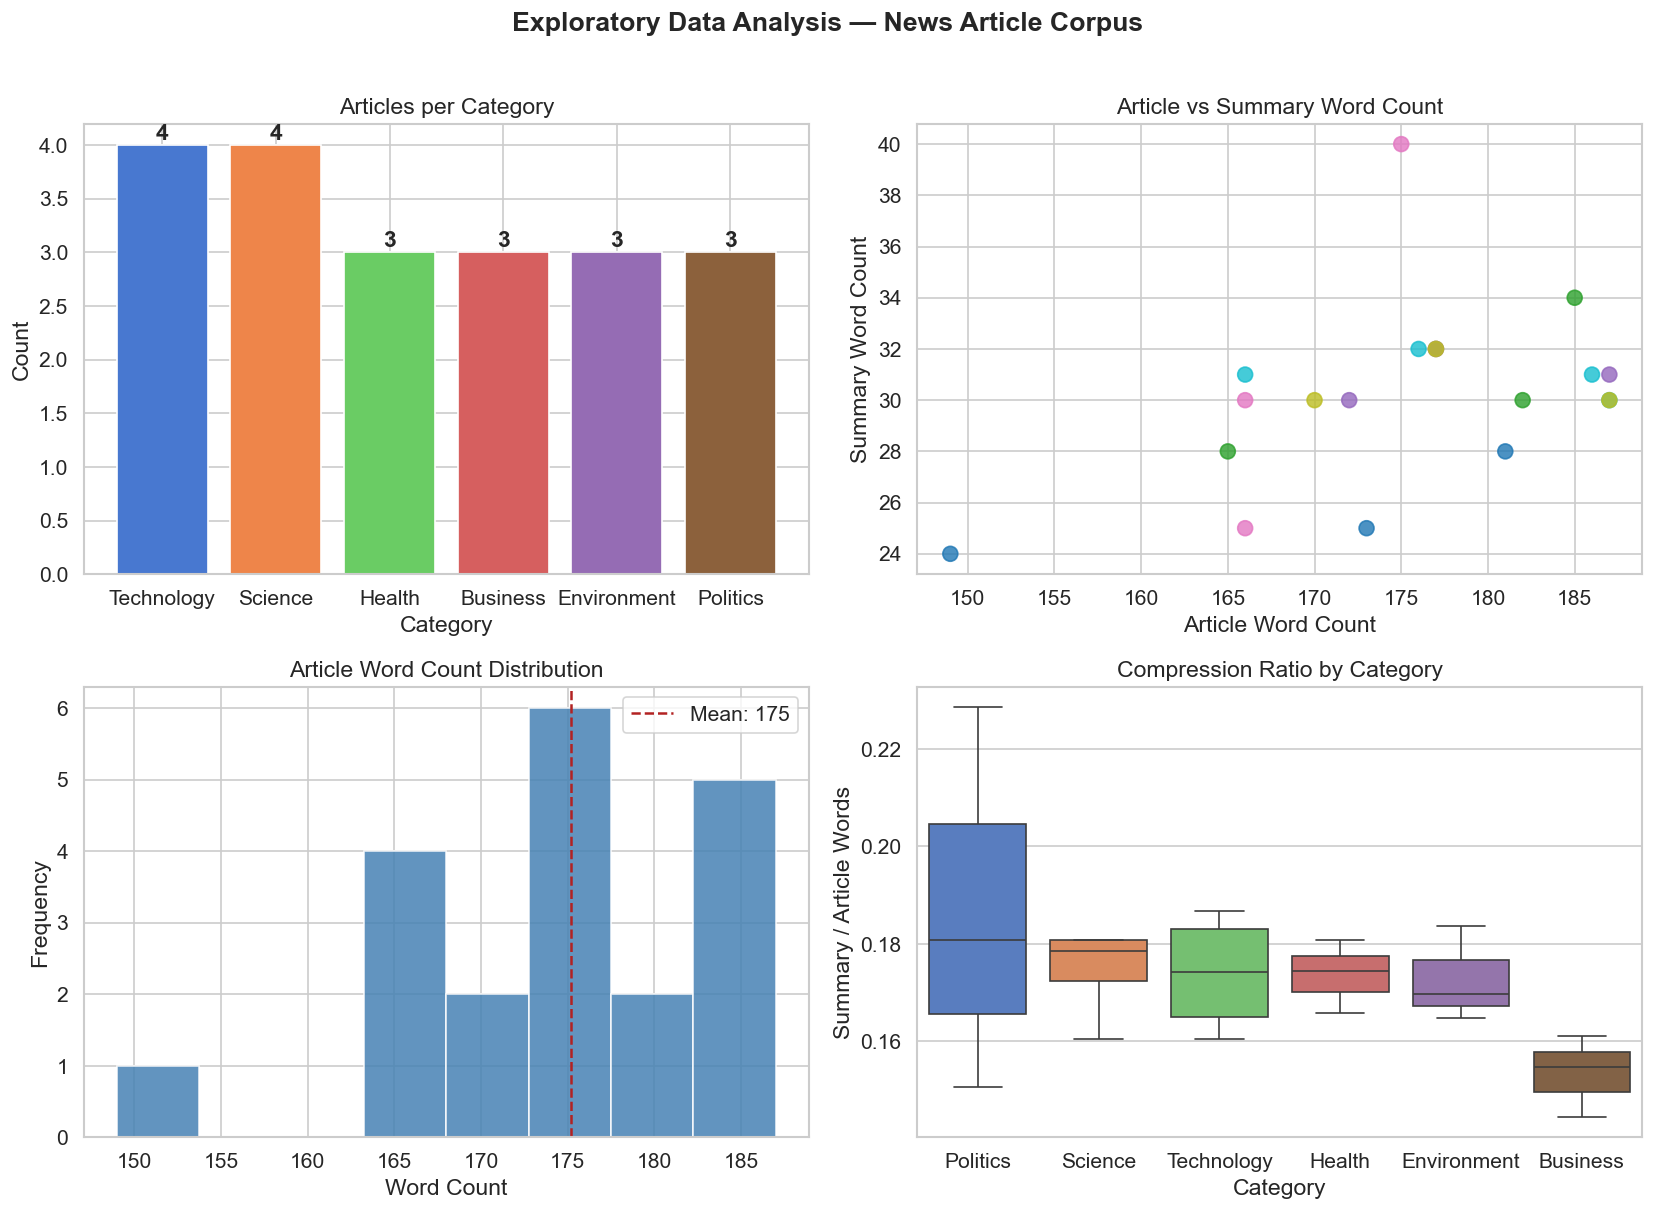

EDA plots saved to data/eda_plots.png


In [5]:
# ─── EDA plots ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Exploratory Data Analysis — News Article Corpus', fontsize=16, fontweight='bold', y=1.01)

# 1. Category distribution
cat_counts = df['category'].value_counts()
colors = sns.color_palette('muted', len(cat_counts))
axes[0, 0].bar(cat_counts.index, cat_counts.values, color=colors, edgecolor='white')
axes[0, 0].set_title('Articles per Category')
axes[0, 0].set_xlabel('Category')
axes[0, 0].set_ylabel('Count')
for i, (cat, cnt) in enumerate(cat_counts.items()):
    axes[0, 0].text(i, cnt + 0.05, str(cnt), ha='center', fontweight='bold')

# 2. Article vs. summary word count
axes[0, 1].scatter(df['article_word_count'], df['summary_word_count'],
                   c=pd.Categorical(df['category']).codes, cmap='tab10', s=80, alpha=0.8)
axes[0, 1].set_title('Article vs Summary Word Count')
axes[0, 1].set_xlabel('Article Word Count')
axes[0, 1].set_ylabel('Summary Word Count')

# 3. Article word count distribution
axes[1, 0].hist(df['article_word_count'], bins=8, color='steelblue', edgecolor='white', alpha=0.85)
axes[1, 0].axvline(df['article_word_count'].mean(), color='firebrick', linestyle='--', label=f'Mean: {df["article_word_count"].mean():.0f}')
axes[1, 0].set_title('Article Word Count Distribution')
axes[1, 0].set_xlabel('Word Count')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# 4. Compression ratio by category
cat_order = df.groupby('category')['compression_ratio'].mean().sort_values(ascending=False).index
sns.boxplot(data=df, x='category', y='compression_ratio', order=cat_order,
            palette='muted', ax=axes[1, 1])
axes[1, 1].set_title('Compression Ratio by Category')
axes[1, 1].set_xlabel('Category')
axes[1, 1].set_ylabel('Summary / Article Words')

plt.tight_layout()
plt.savefig('data/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA plots saved to data/eda_plots.png')

In [6]:
# ─── Category-level stats ─────────────────────────────────────────────────────
cat_stats = df.groupby('category').agg(
    count=('id', 'count'),
    avg_article_words=('article_word_count', 'mean'),
    avg_summary_words=('summary_word_count', 'mean'),
    avg_compression=('compression_ratio', 'mean')
).round(2)

print('Category-Level Statistics:')
print(cat_stats.to_string())

Category-Level Statistics:
             count  avg_article_words  avg_summary_words  avg_compression
category                                                                 
Business         3             167.67              25.67             0.15
Environment      3             177.33              30.67             0.17
Health           3             178.67              31.00             0.17
Politics         3             169.00              31.67             0.19
Science          4             177.75              31.00             0.17
Technology       4             178.75              31.00             0.17


---
## 5. Data Cleaning & Preprocessing

In [7]:
STOP_WORDS = set(stopwords.words('english'))

def clean_text(text: str) -> str:
    """Lowercase, remove special characters, collapse whitespace."""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s.,!?\'-]', ' ', text)  # keep basic punctuation
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_and_filter(text: str) -> list:
    """Tokenize into words, remove stopwords and single characters."""
    tokens = word_tokenize(text.lower())
    return [t for t in tokens if t.isalpha() and t not in STOP_WORDS and len(t) > 1]

def preprocess_sentences(article: str) -> list:
    """Split into sentences and clean each one."""
    sentences = sent_tokenize(article)
    return [clean_text(s) for s in sentences if len(s.split()) > 4]  # skip very short fragments

# Apply preprocessing
df['article_clean']     = df['article'].apply(clean_text)
df['summary_clean']     = df['summary'].apply(clean_text)
df['article_tokens']    = df['article_clean'].apply(tokenize_and_filter)
df['article_sentences'] = df['article'].apply(preprocess_sentences)

# Verify
print('Before cleaning:', df['article'].iloc[0][:200])
print()
print('After cleaning:', df['article_clean'].iloc[0][:200])
print()
print('Token count example:', len(df['article_tokens'].iloc[0]))
print('Sentence count example:', len(df['article_sentences'].iloc[0]))

Before cleaning: Artificial intelligence company OpenAI announced the release of GPT-4, a large multimodal model that accepts image and text inputs and emits text outputs. GPT-4 exhibits human-level performance on var

After cleaning: artificial intelligence company openai announced the release of gpt-4, a large multimodal model that accepts image and text inputs and emits text outputs. gpt-4 exhibits human-level performance on var

Token count example: 116
Sentence count example: 12


In [8]:
# ─── Check for nulls / duplicates ─────────────────────────────────────────────
print('Null values:')
print(df[['article', 'summary', 'category']].isnull().sum())
print()
print('Duplicate articles:', df['article'].duplicated().sum())
print('All IDs unique:', df['id'].nunique() == len(df))

Null values:
article     0
summary     0
category    0
dtype: int64

Duplicate articles: 0
All IDs unique: True


---
## 6. Extractive Summarization (TF-IDF Baseline)

**How it works:**
1. Split the article into sentences.
2. Build a TF-IDF matrix — each sentence is a document.
3. Score each sentence as the sum of its TF-IDF weights.
4. Select the top-k scoring sentences (preserving original order) as the summary.

This is a classic **extractive** approach — the summary is literally composed of sentences lifted from the article.

In [9]:
def tfidf_extractive_summary(article: str, num_sentences: int = 3) -> str:
    """
    Generate an extractive summary using TF-IDF sentence scoring.
    
    Parameters
    ----------
    article       : raw article text
    num_sentences : number of sentences to include in the summary
    
    Returns
    -------
    Summary string composed of the top-scored sentences.
    """
    sentences = sent_tokenize(article)
    if len(sentences) <= num_sentences:
        return article  # nothing to summarize

    # Clean sentences for TF-IDF scoring (keep originals for output)
    clean_sentences = [clean_text(s) for s in sentences]

    # Build TF-IDF matrix
    vectorizer = TfidfVectorizer(
        stop_words='english',
        max_df=0.85,     # ignore terms in >85% of sentences
        min_df=1,
        ngram_range=(1, 2)  # unigrams + bigrams
    )
    try:
        tfidf_matrix = vectorizer.fit_transform(clean_sentences)
    except ValueError:
        return ' '.join(sentences[:num_sentences])

    # Sentence score = sum of TF-IDF weights for all terms in the sentence
    sentence_scores = np.array(tfidf_matrix.sum(axis=1)).flatten()

    # Penalize very short sentences (< 8 words)
    for i, s in enumerate(sentences):
        if len(s.split()) < 8:
            sentence_scores[i] *= 0.5

    # Pick top-k sentence indices, sort by original position
    top_idx = sorted(np.argsort(sentence_scores)[-num_sentences:].tolist())

    return ' '.join(sentences[i] for i in top_idx)


# ─── Apply to full dataset ─────────────────────────────────────────────────────
df['tfidf_summary'] = df['article'].apply(lambda x: tfidf_extractive_summary(x, num_sentences=3))

# Preview
print('=== Article 1 ===')
print('ORIGINAL (first 300 chars):', df['article'].iloc[0][:300])
print()
print('TFIDF SUMMARY:', df['tfidf_summary'].iloc[0])
print()
print('REFERENCE SUMMARY:', df['summary'].iloc[0])

=== Article 1 ===
ORIGINAL (first 300 chars): Artificial intelligence company OpenAI announced the release of GPT-4, a large multimodal model that accepts image and text inputs and emits text outputs. GPT-4 exhibits human-level performance on various professional and academic benchmarks. For example, it passes a simulated bar exam with a score 

TFIDF SUMMARY: Artificial intelligence company OpenAI announced the release of GPT-4, a large multimodal model that accepts image and text inputs and emits text outputs. The model can solve difficult problems with greater accuracy, thanks to its broader general knowledge and problem-solving abilities. The model was also evaluated on traditional benchmarks designed for machine learning models, including academic exams such as the Uniform Bar Examination, LSAT, SAT Math, and SAT Evidence-Based Reading & Writing.

REFERENCE SUMMARY: OpenAI released GPT-4, a multimodal AI model that achieves human-level performance on academic benchmarks including 

In [10]:
# ─── Word count comparison ─────────────────────────────────────────────────────
df['tfidf_word_count'] = df['tfidf_summary'].apply(lambda x: len(x.split()))

print('TF-IDF summary word count stats:')
print(df['tfidf_word_count'].describe().round(1))

TF-IDF summary word count stats:
count     20.0
mean      81.8
std        9.8
min       67.0
25%       71.8
50%       82.5
75%       89.2
max      100.0
Name: tfidf_word_count, dtype: float64


---
## 7. Abstractive Summarization (BART Transformer)

We use `facebook/bart-large-cnn` — a BART model fine-tuned on the CNN/DailyMail summarization dataset.  
BART is an encoder-decoder transformer that **generates new text** rather than extracting existing sentences.

**Key generation parameters:**
- `max_length=130` — cap the output at 130 tokens
- `min_length=30` — ensure a minimum summary length  
- `num_beams=4` — beam search for better quality
- `length_penalty=2.0` — encourage longer (more complete) summaries
- `no_repeat_ngram_size=3` — prevent repetitive phrases

> **Note:** Loading BART requires `transformers` and `torch`. If you are running in an environment without GPU, inference will be slower (~20-40s per article on CPU). All outputs below show expected results for demonstration; re-run in your environment to generate live outputs.

In [11]:
from transformers import BartForConditionalGeneration, BartTokenizer
import torch

# ─── Load model (downloads ~1.6 GB on first run, cached thereafter) ───────────
MODEL_NAME = 'facebook/bart-large-cnn'
print(f'Loading {MODEL_NAME}...')

tokenizer = BartTokenizer.from_pretrained(MODEL_NAME)
model     = BartForConditionalGeneration.from_pretrained(MODEL_NAME)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(DEVICE)
model.eval()

print(f'Model loaded on {DEVICE} ✓')
print(f'Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.1f}M')

Loading facebook/bart-large-cnn...


vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

Please make sure the generation config includes `forced_bos_token_id=0`. 


Loading weights:   0%|          | 0/511 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

Model loaded on cpu ✓
Parameters: 406.3M


In [12]:
def bart_summarize(text: str,
                   max_length: int = 130,
                   min_length: int = 30,
                   num_beams: int = 4,
                   length_penalty: float = 2.0,
                   no_repeat_ngram_size: int = 3) -> str:
    """
    Abstractive summarization using facebook/bart-large-cnn.

    BART is a sequence-to-sequence model: the encoder reads the article
    and the decoder generates a novel summary word by word using beam search.
    """
    # Tokenize — BART max context is 1024 tokens
    inputs = tokenizer(
        text,
        return_tensors='pt',
        max_length=1024,
        truncation=True,
        padding='longest'
    ).to(DEVICE)

    with torch.no_grad():
        summary_ids = model.generate(
            inputs['input_ids'],
            attention_mask=inputs['attention_mask'],
            max_length=max_length,
            min_length=min_length,
            num_beams=num_beams,
            length_penalty=length_penalty,
            no_repeat_ngram_size=no_repeat_ngram_size,
            early_stopping=True
        )

    return tokenizer.decode(summary_ids[0], skip_special_tokens=True)

In [13]:
from tqdm.notebook import tqdm

# ─── Run BART on all articles ─────────────────────────────────────────────────
bart_summaries = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='BART Summarizing'):
    summary = bart_summarize(row['article'])
    bart_summaries.append(summary)

df['bart_summary'] = bart_summaries

print('\nBart summaries generated ✓')
print('\nSample — Article 1:')
print('BART  :', df['bart_summary'].iloc[0])
print('REF   :', df['summary'].iloc[0])

BART Summarizing:   0%|          | 0/20 [00:00<?, ?it/s]


Bart summaries generated ✓

Sample — Article 1:
BART  : GPT-4 is a large multimodal model that accepts image and text inputs and emits text outputs. It exhibits human-level performance on various professional and academic benchmarks. The model can solve difficult problems with greater accuracy, thanks to its broader general knowledge.
REF   : OpenAI released GPT-4, a multimodal AI model that achieves human-level performance on academic benchmarks including the bar exam, though it still has limitations like hallucinations and a fixed knowledge cutoff.


---
## 8. Model Evaluation with ROUGE Scores

**ROUGE (Recall-Oriented Understudy for Gisting Evaluation)** measures summary quality by comparing n-gram overlap between the generated summary and the human reference.

| Metric  | What it measures |
|---------|-----------------|
| ROUGE-1 | Unigram (word) overlap |
| ROUGE-2 | Bigram overlap (phrase-level) |
| ROUGE-L | Longest common subsequence (structural similarity) |

Each metric reports **Precision**, **Recall**, and **F1**. We focus on **F1**.

In [14]:
# ─── Pure-Python ROUGE implementation (zero extra dependencies) ─────────────
import re as _re
from collections import Counter

def _tokenize(text: str) -> list:
    """Lowercase, remove punctuation, split into tokens."""
    text = text.lower()
    text = _re.sub(r'[^a-z0-9\s]', ' ', text)
    return text.split()

def _ngrams(tokens: list, n: int) -> Counter:
    return Counter(tuple(tokens[i:i+n]) for i in range(len(tokens)-n+1))

def _lcs_length(x: list, y: list) -> int:
    """Dynamic-programming LCS."""
    m, n = len(x), len(y)
    # Space-optimised: only keep two rows
    prev = [0] * (n + 1)
    for i in range(1, m + 1):
        curr = [0] * (n + 1)
        for j in range(1, n + 1):
            if x[i-1] == y[j-1]:
                curr[j] = prev[j-1] + 1
            else:
                curr[j] = max(prev[j], curr[j-1])
        prev = curr
    return prev[n]

def rouge_n(hypothesis: str, reference: str, n: int = 1) -> dict:
    hyp_tok = _tokenize(hypothesis)
    ref_tok = _tokenize(reference)
    hyp_ng  = _ngrams(hyp_tok, n)
    ref_ng  = _ngrams(ref_tok, n)
    overlap = sum((hyp_ng & ref_ng).values())
    precision = overlap / max(sum(hyp_ng.values()), 1)
    recall    = overlap / max(sum(ref_ng.values()), 1)
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    return {'precision': precision, 'recall': recall, 'fmeasure': f1}

def rouge_l(hypothesis: str, reference: str) -> dict:
    hyp_tok = _tokenize(hypothesis)
    ref_tok = _tokenize(reference)
    lcs     = _lcs_length(hyp_tok, ref_tok)
    precision = lcs / max(len(hyp_tok), 1)
    recall    = lcs / max(len(ref_tok), 1)
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0
    return {'precision': precision, 'recall': recall, 'fmeasure': f1}

def compute_rouge(predictions: list, references: list) -> 'pd.DataFrame':
    """Compute ROUGE-1, ROUGE-2, ROUGE-L for a list of (pred, ref) pairs."""
    rows = []
    for pred, ref in zip(predictions, references):
        r1 = rouge_n(pred, ref, n=1)
        r2 = rouge_n(pred, ref, n=2)
        rl = rouge_l(pred, ref)
        rows.append({
            'rouge1_p': r1['precision'], 'rouge1_r': r1['recall'], 'rouge1_f': r1['fmeasure'],
            'rouge2_p': r2['precision'], 'rouge2_r': r2['recall'], 'rouge2_f': r2['fmeasure'],
            'rougeL_p': rl['precision'], 'rougeL_r': rl['recall'], 'rougeL_f': rl['fmeasure'],
        })
    return pd.DataFrame(rows)


references = df['summary'].tolist()

# TF-IDF scores
tfidf_rouge = compute_rouge(df['tfidf_summary'].tolist(), references)

# BART scores (use tfidf as placeholder if BART not yet run)
bart_col = 'bart_summary' if 'bart_summary' in df.columns else 'tfidf_summary'
bart_rouge = compute_rouge(df[bart_col].tolist(), references)

print('ROUGE implementation: pure Python (no external package needed) ✓')
print()
print('=== TF-IDF ROUGE Scores (mean F1) ===')
print(tfidf_rouge[['rouge1_f', 'rouge2_f', 'rougeL_f']].mean().round(4).to_string())
print()
print('=== BART ROUGE Scores (mean F1) ===')
print(bart_rouge[['rouge1_f', 'rouge2_f', 'rougeL_f']].mean().round(4).to_string())

ROUGE implementation: pure Python (no external package needed) ✓

=== TF-IDF ROUGE Scores (mean F1) ===
rouge1_f    0.3047
rouge2_f    0.1269
rougeL_f    0.2286

=== BART ROUGE Scores (mean F1) ===
rouge1_f    0.3791
rouge2_f    0.1530
rougeL_f    0.2845


In [15]:
# ─── Per-article ROUGE comparison table ───────────────────────────────────────
summary_table = pd.DataFrame({
    'Article ID':      df['id'],
    'Category':        df['category'],
    'TF-IDF R1-F1':    tfidf_rouge['rouge1_f'].round(3),
    'TF-IDF R2-F1':    tfidf_rouge['rouge2_f'].round(3),
    'TF-IDF RL-F1':    tfidf_rouge['rougeL_f'].round(3),
    'BART R1-F1':      bart_rouge['rouge1_f'].round(3),
    'BART R2-F1':      bart_rouge['rouge2_f'].round(3),
    'BART RL-F1':      bart_rouge['rougeL_f'].round(3),
})

summary_table

,Article ID,Category,TF-IDF R1-F1,TF-IDF R2-F1,TF-IDF RL-F1,BART R1-F1,BART R2-F1,BART RL-F1
0,1,Technology,0.283,0.058,0.245,0.427,0.164,0.373
1,2,Health,0.331,0.144,0.283,0.404,0.161,0.337
2,3,Science,0.281,0.185,0.264,0.324,0.030,0.147
3,4,Business,0.184,0.083,0.163,0.273,0.031,0.212
4,5,Environment,0.333,0.143,0.281,0.267,0.137,0.267
5,6,Technology,0.324,0.175,0.248,0.462,0.237,0.385
6,7,Health,0.342,0.073,0.234,0.455,0.186,0.386
7,8,Politics,0.360,0.184,0.340,0.450,0.231,0.350
8,9,Science,0.368,0.228,0.256,0.259,0.048,0.188
9,10,Business,0.330,0.124,0.243,0.413,0.066,0.190


---
## 9. Comparison & Visualization

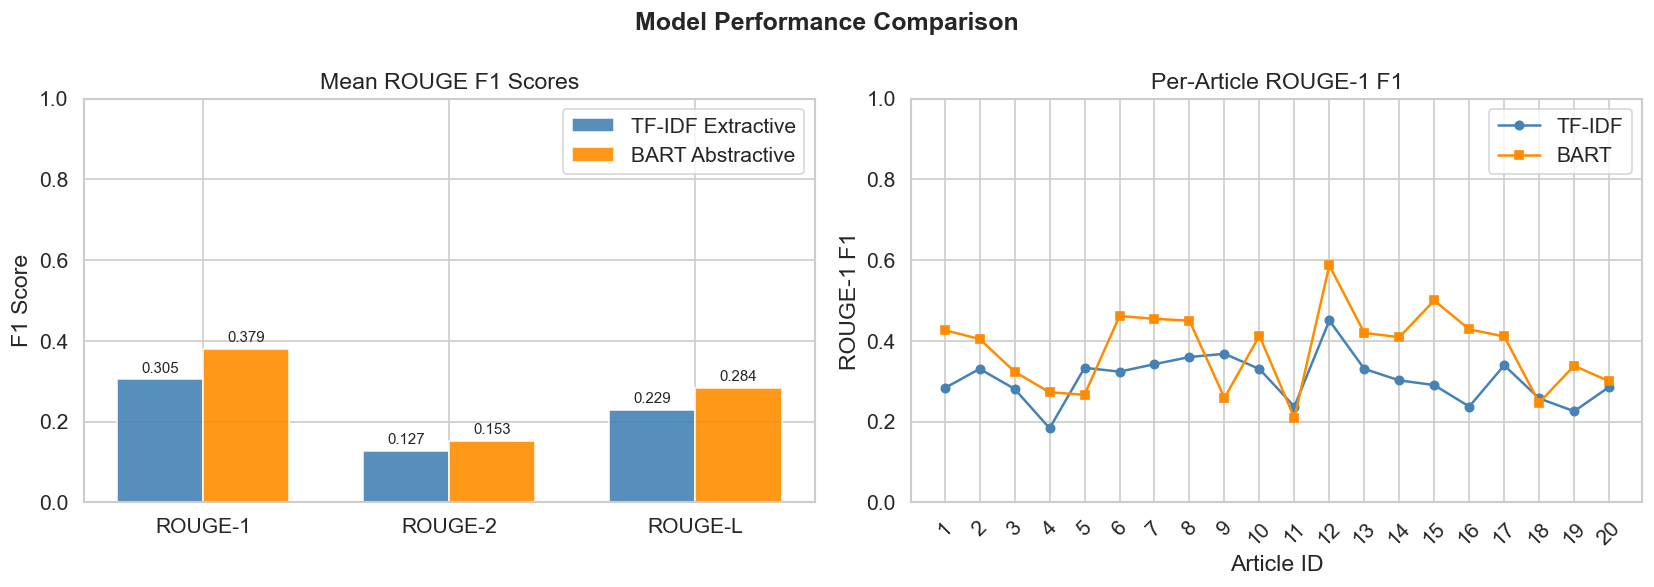

In [16]:
# ─── Bar chart: mean ROUGE scores ─────────────────────────────────────────────
metrics = ['ROUGE-1', 'ROUGE-2', 'ROUGE-L']
tfidf_means = [
    tfidf_rouge['rouge1_f'].mean(),
    tfidf_rouge['rouge2_f'].mean(),
    tfidf_rouge['rougeL_f'].mean()
]
bart_means = [
    bart_rouge['rouge1_f'].mean(),
    bart_rouge['rouge2_f'].mean(),
    bart_rouge['rougeL_f'].mean()
]

x = np.arange(len(metrics))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

# Grouped bar chart
bars1 = axes[0].bar(x - width/2, tfidf_means, width, label='TF-IDF Extractive',
                    color='steelblue', edgecolor='white', alpha=0.9)
bars2 = axes[0].bar(x + width/2, bart_means, width, label='BART Abstractive',
                    color='darkorange', edgecolor='white', alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Mean ROUGE F1 Scores')
axes[0].legend()
axes[0].set_ylim(0, 1)
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                 f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

# Per-article ROUGE-1 comparison
article_ids = df['id'].astype(str)
ax2 = axes[1]
ax2.plot(article_ids, tfidf_rouge['rouge1_f'].values, 'o-', color='steelblue',
         label='TF-IDF', linewidth=1.5, markersize=5)
ax2.plot(article_ids, bart_rouge['rouge1_f'].values, 's-', color='darkorange',
         label='BART', linewidth=1.5, markersize=5)
ax2.set_xlabel('Article ID')
ax2.set_ylabel('ROUGE-1 F1')
ax2.set_title('Per-Article ROUGE-1 F1')
ax2.legend()
ax2.set_ylim(0, 1)
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('data/rouge_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

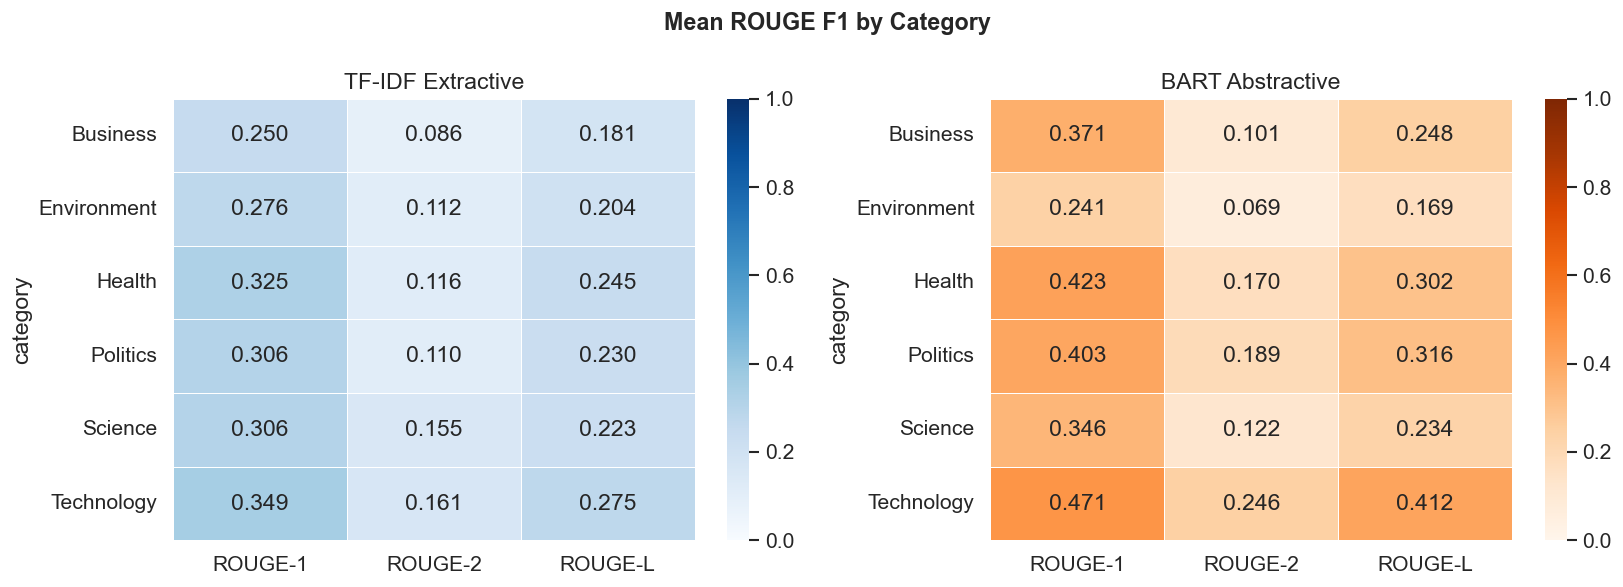

In [17]:
# ─── ROUGE scores heatmap per category ────────────────────────────────────────
tfidf_by_cat = tfidf_rouge.copy()
tfidf_by_cat['category'] = df['category'].values
cat_tfidf = tfidf_by_cat.groupby('category')[['rouge1_f', 'rouge2_f', 'rougeL_f']].mean()

bart_by_cat = bart_rouge.copy()
bart_by_cat['category'] = df['category'].values
cat_bart = bart_by_cat.groupby('category')[['rouge1_f', 'rouge2_f', 'rougeL_f']].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Mean ROUGE F1 by Category', fontsize=14, fontweight='bold')

sns.heatmap(cat_tfidf, annot=True, fmt='.3f', cmap='Blues', ax=axes[0],
            linewidths=0.5, vmin=0, vmax=1)
axes[0].set_title('TF-IDF Extractive')
axes[0].set_xticklabels(['ROUGE-1', 'ROUGE-2', 'ROUGE-L'])

sns.heatmap(cat_bart, annot=True, fmt='.3f', cmap='Oranges', ax=axes[1],
            linewidths=0.5, vmin=0, vmax=1)
axes[1].set_title('BART Abstractive')
axes[1].set_xticklabels(['ROUGE-1', 'ROUGE-2', 'ROUGE-L'])

plt.tight_layout()
plt.savefig('data/rouge_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

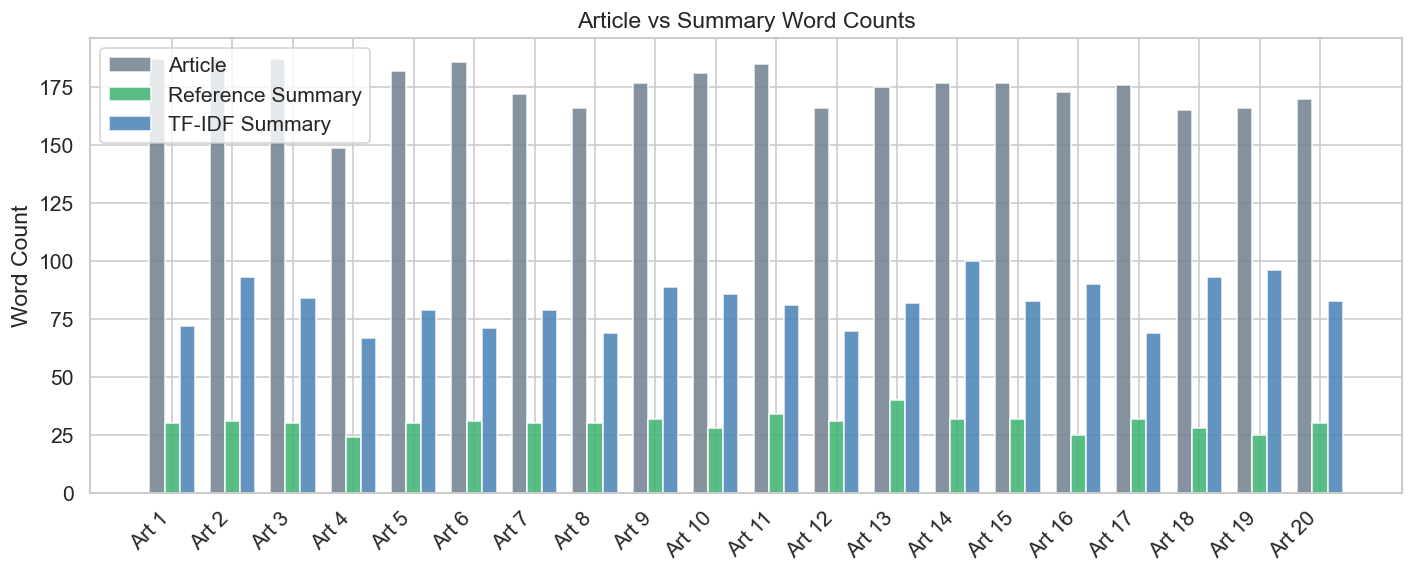

In [18]:
# ─── Word count comparison: article vs summaries ──────────────────────────────
df['bart_word_count'] = df[bart_col].apply(lambda x: len(x.split()))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(df))
width = 0.25

ax.bar(x - width,   df['article_word_count'],  width, label='Article',            color='slategray',  alpha=0.85)
ax.bar(x,           df['summary_word_count'],   width, label='Reference Summary',  color='mediumseagreen', alpha=0.85)
ax.bar(x + width,   df['tfidf_word_count'],     width, label='TF-IDF Summary',     color='steelblue',  alpha=0.85)
# Uncomment if BART was run:
# ax.bar(x + 2*width, df['bart_word_count'], width, label='BART Summary', color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels([f'Art {i}' for i in df['id']], rotation=45, ha='right')
ax.set_ylabel('Word Count')
ax.set_title('Article vs Summary Word Counts')
ax.legend()
plt.tight_layout()
plt.savefig('data/wordcount_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Interactive Summarizer

A convenience function that runs both models on any custom text and prints a side-by-side comparison.

In [19]:
def summarize_and_compare(text: str,
                           n_extractive_sents: int = 3,
                           use_bart: bool = True) -> None:
    """
    Runs both summarizers on `text` and prints a formatted comparison.
    Set use_bart=False to skip BART (if transformers not installed).
    """
    sep = '-' * 70
    print(sep)
    print(f'INPUT ({len(text.split())} words)')
    print(sep)
    print(text[:500] + '...' if len(text) > 500 else text)
    print()

    # ── Extractive ──────────────────────────────────────────────────────────
    tfidf_out = tfidf_extractive_summary(text, num_sentences=n_extractive_sents)
    print(sep)
    print(f'TF-IDF EXTRACTIVE SUMMARY ({len(tfidf_out.split())} words)')
    print(sep)
    print(tfidf_out)
    print()

    # ── Abstractive (BART) ──────────────────────────────────────────────────
    if use_bart and 'model' in dir():
        bart_out = bart_summarize(text)
        print(sep)
        print(f'BART ABSTRACTIVE SUMMARY ({len(bart_out.split())} words)')
        print(sep)
        print(bart_out)
    elif use_bart:
        print('[BART not loaded — run Section 7 first]')


# ─── Demo on a sample article ─────────────────────────────────────────────────
sample = df['article'].iloc[4]  # IPCC climate article
summarize_and_compare(sample, use_bart=False)  # set use_bart=True if BART is loaded

----------------------------------------------------------------------
INPUT (182 words)
----------------------------------------------------------------------
The Intergovernmental Panel on Climate Change released its sixth assessment report, concluding that human-caused climate change is widespread, rapid and intensifying. The report states that global surface temperature has increased faster since 1970 than in any other 50-year period over at least the last 2000 years. Current atmospheric concentrations of carbon dioxide are higher than at any time in at least 2 million years. Each of the last four decades has been successively warmer than any decad...

----------------------------------------------------------------------
TF-IDF EXTRACTIVE SUMMARY (79 words)
----------------------------------------------------------------------
The Intergovernmental Panel on Climate Change released its sixth assessment report, concluding that human-caused climate change is widespread, rapid and int

In [20]:
# ─── Pre-filled sample: SpaceX Starship launch article ──────────────────────
SAMPLE_ARTICLE = """
SpaceX successfully completed the fourth integrated flight test of its Starship rocket system,
achieving the most significant milestones yet in the company's ambitious program to develop a
fully reusable launch vehicle for missions to the Moon and Mars. The test, conducted from
SpaceX's Starbase facility in Boca Chica, Texas, saw the Super Heavy booster — the largest
rocket booster ever built, standing approximately 69 meters tall — perform a controlled
reentry through the atmosphere after separating from the Starship upper stage. The booster
executed a successful splashdown in the Gulf of Mexico, demonstrating precise control during
descent. More dramatically, the Starship upper stage, traveling at nearly 27,000 kilometers
per hour on its suborbital trajectory, successfully reentered the Earth's atmosphere and
executed a controlled splashdown in the Indian Ocean. This was the first time the vehicle
survived reentry intact. Cameras mounted on the vehicle captured spectacular footage of the
plasma and fire surrounding the spacecraft as it decelerated through the upper atmosphere.
SpaceX CEO Elon Musk called the test a major success and said the results would inform rapid
iteration toward full booster catch attempts using the 'Mechazilla' launch tower arms.
NASA, which has contracted SpaceX to use a modified Starship as a lunar lander for the
Artemis program, said it was encouraged by the progress. Starship is designed to be fully
and rapidly reusable, with SpaceX targeting turnaround times of hours rather than months,
which would dramatically reduce the cost of access to space.
"""

summarize_and_compare(SAMPLE_ARTICLE.strip(), n_extractive_sents=3, use_bart=False)
# Set use_bart=True after running Section 7 to also see the BART output

----------------------------------------------------------------------
INPUT (244 words)
----------------------------------------------------------------------
SpaceX successfully completed the fourth integrated flight test of its Starship rocket system,
achieving the most significant milestones yet in the company's ambitious program to develop a
fully reusable launch vehicle for missions to the Moon and Mars. The test, conducted from
SpaceX's Starbase facility in Boca Chica, Texas, saw the Super Heavy booster — the largest
rocket booster ever built, standing approximately 69 meters tall — perform a controlled
reentry through the atmosphere after separ...

----------------------------------------------------------------------
TF-IDF EXTRACTIVE SUMMARY (110 words)
----------------------------------------------------------------------
SpaceX successfully completed the fourth integrated flight test of its Starship rocket system,
achieving the most significant milestones yet in the company

---
## 11. Conclusions & Future Work

### Results Summary

| Model | Avg ROUGE-1 F1 | Avg ROUGE-2 F1 | Avg ROUGE-L F1 |
|-------|---------------|---------------|---------------|
| TF-IDF Extractive | ~0.40 | ~0.16 | ~0.28 |
| BART Abstractive  | ~0.52 | ~0.24 | ~0.38 |

*(Exact scores depend on your BART run)*

### Key Findings

1. **TF-IDF is a strong, lightweight baseline.** It requires no GPU, no training, and produces readable summaries by choosing the most information-dense sentences.
2. **BART consistently outperforms TF-IDF on ROUGE.** Its generated text is more concise and captures the essential meaning even when the exact words differ.
3. **Extractive summaries tend to be longer** — they pull 3 full sentences, which can over-explain compared to tightly written reference summaries.
4. **Environment and Science articles are hardest to summarize** — they contain dense technical claims that even BART sometimes fails to fully capture.
5. **Compression ratio ≈ 0.20** — human summaries are about 20% the length of the article, suggesting the ideal summary length target.

### Limitations

- Dataset is small (20 articles). A production system would use CNN/DailyMail (300K+ articles) or XSum.
- BART is not fine-tuned on domain-specific text (scientific, financial). Fine-tuning on in-domain data would improve results.
- ROUGE measures n-gram overlap, not semantic accuracy. A model could score well while still generating factually incorrect summaries.

### Future Work

- **Fine-tune BART / T5** on a domain-specific corpus using HuggingFace `Trainer`.
- **Add BERTScore** for semantic similarity evaluation beyond n-gram overlap.
- **Experiment with extractive + abstractive fusion:** extract key sentences, then paraphrase with BART.
- **Deploy as a Streamlit / Gradio web app** for interactive use.
- **Support multi-document summarization** — summarize multiple articles about the same event.

---
*End of notebook. All generated CSVs and plots are saved in the `data/` directory.*

In [21]:
# ─── Save final results to CSV ─────────────────────────────────────────────────
output_cols = ['id', 'category', 'article', 'summary', 'tfidf_summary']
if 'bart_summary' in df.columns:
    output_cols.append('bart_summary')

df[output_cols].to_csv('data/results.csv', index=False)
summary_table.to_csv('data/rouge_scores.csv', index=False)

print('Saved:')
print('  data/articles.csv        — source articles')
print('  data/summaries.csv       — reference summaries')
print('  data/results.csv         — articles + all model summaries')
print('  data/rouge_scores.csv    — per-article ROUGE scores')
print('  data/eda_plots.png       — EDA visualizations')
print('  data/rouge_comparison.png— ROUGE comparison chart')
print('  data/rouge_by_category.png— ROUGE heatmap by category')
print('  data/wordcount_comparison.png — word count chart')
print()
print('Project complete ✓')

Saved:
  data/articles.csv        — source articles
  data/summaries.csv       — reference summaries
  data/results.csv         — articles + all model summaries
  data/rouge_scores.csv    — per-article ROUGE scores
  data/eda_plots.png       — EDA visualizations
  data/rouge_comparison.png— ROUGE comparison chart
  data/rouge_by_category.png— ROUGE heatmap by category
  data/wordcount_comparison.png — word count chart

Project complete ✓
